# Traffic Fingerprinting — Distinzione delle applicazioni dal traffico di rete cifrato

**Tesi: Traffic Fingerprinting su OpenWrt — Stadio 2**

## Obiettivo
> **È possibile distinguere quale applicazione specifica sta scaricando dati, osservando solo il traffico di rete cifrato (senza decifrarne il contenuto)?**

L'analisi viene condotta su catture di traffico raccolte tramite un testbed OpenWrt (Raspberry Pi 4 + adattatore MediaTek MT7612U), utilizzando OpenAppFilter come sistema di riconoscimento.

## Metodologia in breve

Per ciascuna applicazione testata è stato applicato un *protocollo ad alternanza*: una prima fase con la regola OAF attiva (per registrare l'evento di riconoscimento), seguita da una fase con la regola disattivata durante la quale il download avviene liberamente ed è catturato con `tcpdump` sull'interfaccia `br-lan`.

## Dataset raccolto

**9 applicazioni** con **6 ripetizioni** ciascuna (Calcolatrice, Canva, Corriere della Sera, Disney+, IKEA, Shazam, Trivago, UPS, Unieuro), più **2 campioni parziali** (Genshin Impact e Hay Day), interrotti per un limite hardware del testbed.

## Struttura del notebook

1. Caricamento ed estrazione veloce delle catture
2. Analisi descrittiva (confronto tra applicazioni per volume di traffico)
3. Feature avanzate: direzione del traffico e pacchetti "pesanti"
4. Feature mirate aggiuntive: tempo di inter-arrivo (IAT) e distribuzione delle dimensioni
5. Classificazione con Random Forest (validazione *leave-one-out*)
6. Verifica e ottimizzazione (ricerca iperparametri, confronto con XGBoost)
7. Analisi approfondita del caso residuo Canva / UPS
8. Esperimenti di *classificazione precoce* (primi N pacchetti)
9. Sintesi finale dei risultati


## 1. Setup dell'ambiente

Librerie utilizzate:
- `scapy` — per la lettura mirata di un numero limitato di pacchetti (es. i primi N), dove serve interpretare correttamente gli strati del protocollo
- `struct` / `socket` — per una lettura **manuale e molto più veloce** del formato `.pcap`, usata per le catture di grandi dimensioni (fino a 878 MB per il campione parziale di Genshin Impact), dove la decodifica completa di `scapy` risulterebbe troppo lenta
- `pandas` / `numpy` — gestione tabellare dei dati
- `matplotlib` — visualizzazioni
- `scikit-learn` / `xgboost` — classificazione e validazione


In [2]:
from scapy.all import rdpcap
from scapy.layers.inet import IP
import pandas as pd
import numpy as np
import struct
import socket
import os
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

print("Librerie caricate correttamente.")

Librerie caricate correttamente.


## 2. Caricamento automatico dei file di cattura

Con oltre 50 file di cattura raccolti, costruire manualmente il dizionario dei percorsi sarebbe lungo e soggetto a errori (già riscontrato in una fase precedente del lavoro: una chiave duplicata aveva silenziosamente escluso un file dall'analisi).

I file vengono quindi individuati **automaticamente** dalla cartella `catture/`, sfruttando la convenzione di denominazione adottata per tutte le raccolte: `cattura_<app>_<numero>.pcap`.


In [3]:
import re

CARTELLA = "catture"

FILES = {}
APP_DI = {}

NOMI_PULITI = {
    "calcolatrice": "Calcolatrice",
    "disney": "Disney+",
    "canva": "Canva",
    "hayday": "Hay Day (parziale)",
    "genshin": "Genshin Impact (parziale)",
    "corriere": "Corriere della Sera",
    "shazam": "Shazam",
    "trivago": "Trivago",
    "unieuro": "Unieuro",
    "ups": "UPS",
    "ikea": "IKEA",
}

for f in sorted(os.listdir(CARTELLA)):
    if not f.endswith(".pcap"):
        continue
    match = re.match(r"cattura_(.+)\.pcap", f)
    if not match:
        continue
    etichetta = match.group(1)
    FILES[etichetta] = os.path.join(CARTELLA, f)
    nome_base = re.sub(r"_\d+$", "", etichetta)
    APP_DI[etichetta] = NOMI_PULITI.get(nome_base, nome_base)

print(f"Trovati {len(FILES)} file di cattura, per {len(set(APP_DI.values()))} applicazioni diverse.")

Trovati 56 file di cattura, per 11 applicazioni diverse.


## 3. Estrazione delle statistiche di base

### Perché non usare `scapy` per tutte le catture

Un primo tentativo di estrazione con `scapy.rdpcap()` si è rivelato **troppo lento** per le catture di grandi dimensioni: il campione parziale di Genshin Impact (878 MB, oltre 680.000 pacchetti) richiedeva diversi minuti solo per essere caricato in memoria.

### La soluzione adottata

Il formato `.pcap` ha una struttura fissa: un'intestazione globale di 24 byte, seguita da record ciascuno preceduto da un header a lunghezza fissa (16 byte) contenente **timestamp** e **lunghezza del pacchetto**. Per le statistiche aggregate non serve interpretare il contenuto dei pacchetti: basta leggere questi header con `struct`, saltando i dati veri e propri,risultati numericamente identici a `scapy`.


In [4]:
def estrai_statistiche_veloce(percorso_file):
    with open(percorso_file, "rb") as f:
        header_globale = f.read(24)
        if len(header_globale) < 24:
            return None

        magic = struct.unpack("I", header_globale[:4])[0]
        if magic == 0xa1b2c3d4:
            endian = "<"
        elif magic == 0xd4c3b2a1:
            endian = ">"
        else:
            return None

        dimensioni = []
        timestamps = []

        while True:
            header_pacchetto = f.read(16)
            if len(header_pacchetto) < 16:
                break
            ts_sec, ts_usec, len_catturata, len_originale = struct.unpack(
                endian + "IIII", header_pacchetto
            )
            timestamps.append(ts_sec + ts_usec / 1_000_000)
            dimensioni.append(len_originale)
            f.seek(len_catturata, 1)

    if not dimensioni:
        return None

    n_pacchetti = len(dimensioni)
    byte_totali = sum(dimensioni)
    durata_sec = timestamps[-1] - timestamps[0]

    return {
        "n_pacchetti": n_pacchetti,
        "byte_totali": byte_totali,
        "MB_totali": round(byte_totali / (1024 * 1024), 2),
        "durata_sec": round(durata_sec, 2),
        "velocita_media_KB_s": round((byte_totali / 1024) / durata_sec, 2) if durata_sec > 0 else 0,
        "dim_pacchetto_media": round(byte_totali / n_pacchetti, 1),
        "dim_pacchetto_min": min(dimensioni),
        "dim_pacchetto_max": max(dimensioni),
    }

In [5]:
risultati = []
for etichetta, percorso in FILES.items():
    if not os.path.exists(percorso):
        print(f"File non trovato, salto: {percorso}")
        continue
    stats = estrai_statistiche_veloce(percorso)
    if stats is None:
        print(f"File vuoto o illeggibile: {percorso}")
        continue
    stats["etichetta"] = etichetta
    stats["app"] = APP_DI.get(etichetta, etichetta)
    risultati.append(stats)

df = pd.DataFrame(risultati)
colonne_ordinate = ["app", "etichetta", "n_pacchetti", "MB_totali", "durata_sec",
                     "velocita_media_KB_s", "dim_pacchetto_media",
                     "dim_pacchetto_min", "dim_pacchetto_max"]
df = df[colonne_ordinate].sort_values(["app", "etichetta"]).reset_index(drop=True)

df.to_csv("statistiche_catture.csv", index=False)
print(f"Estrazione completata: {len(df)} catture elaborate su {len(FILES)} file totali.")
df.head(10)

Estrazione completata: 56 catture elaborate su 56 file totali.


,app,etichetta,n_pacchetti,MB_totali,durata_sec,velocita_media_KB_s,dim_pacchetto_media,dim_pacchetto_min,dim_pacchetto_max
0,Calcolatrice,calcolatrice_1,7180,7.64,16.34,478.54,1115.5,42,1414
1,Calcolatrice,calcolatrice_2,5923,7.07,12.52,578.00,1251.6,54,1414
2,Calcolatrice,calcolatrice_3,5883,7.07,8.60,842.08,1260.7,54,1414
3,Calcolatrice,calcolatrice_4,10362,10.02,39.07,262.63,1014.0,42,1414
4,Calcolatrice,calcolatrice_5,8049,8.54,61.55,142.09,1112.7,42,1463
5,Calcolatrice,calcolatrice_6,8429,8.42,30.72,280.67,1047.4,42,1463
6,Canva,canva_1,89296,92.58,189.60,499.99,1087.1,42,1414
7,Canva,canva_2,72518,76.94,122.86,641.32,1112.6,42,1414
8,Canva,canva_3,54980,65.56,51.96,1292.02,1250.3,42,1463
9,Canva,canva_4,74395,75.99,133.82,581.48,1071.1,42,1414


## 4. Analisi descrittiva: confronto del volume di traffico tra applicazioni

Il **volume totale di traffico** è la prima feature naturale da esaminare. Il grafico seguente usa una **scala logaritmica** sull'asse Y perché i valori spaziano su quasi tre ordini di grandezza (da ~7 MB per Calcolatrice a ~878 MB per il campione parziale di Genshin Impact).


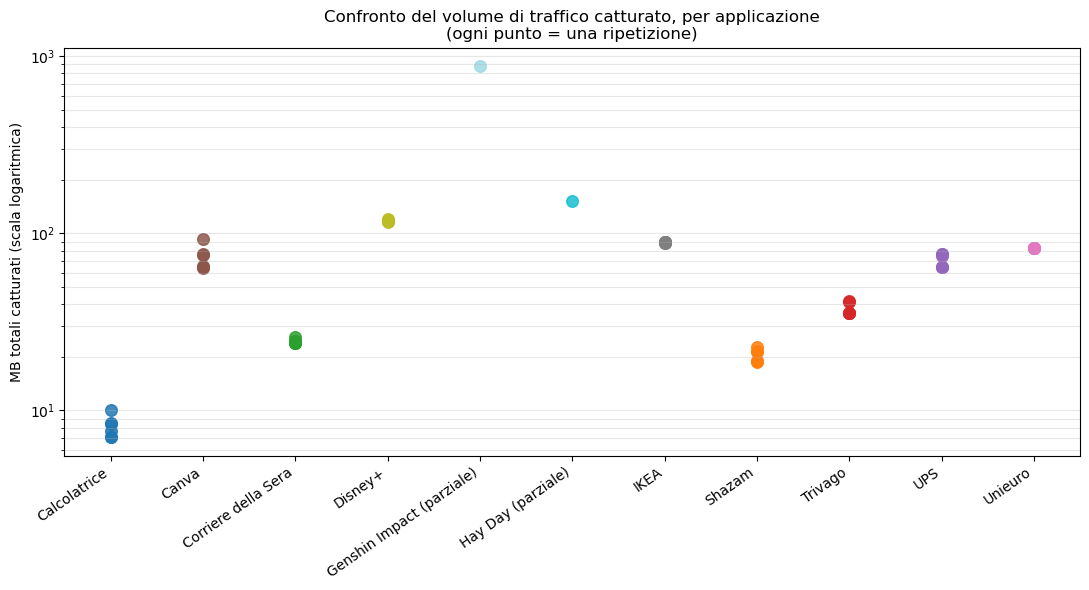

In [7]:
plt.figure(figsize=(11, 6))
app_uniche = sorted(df["app"].unique(), key=lambda a: df[df["app"]==a]["MB_totali"].median())
colori = plt.cm.tab20(np.linspace(0, 1, len(app_uniche)))
colore_per_app = {app: colori[i] for i, app in enumerate(app_uniche)}

for _, riga in df.iterrows():
    plt.scatter(riga["app"], riga["MB_totali"], color=colore_per_app[riga["app"]], s=70, alpha=0.85)

plt.yscale("log")
plt.ylabel("MB totali catturati (scala logaritmica)")
plt.title("Confronto del volume di traffico catturato, per applicazione\n(ogni punto = una ripetizione)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("grafico_mb_totali_log.png", dpi=150)
plt.show()

### Interpretazione

Alcune applicazioni si separano nettamente (**Calcolatrice**, ~7-10 MB; **Disney+**, ~117-120 MB; i campioni parziali di **Hay Day** e **Genshin Impact**, i più pesanti in assoluto). Un gruppo di applicazioni (**Canva, UPS, Unieuro, IKEA**) occupa una fascia di dimensioni sovrapposte (circa 63-93 MB), rendendo la sola dimensione totale insufficiente a distinguerle con certezza. Questa osservazione motiva le feature aggiuntive introdotte nelle sezioni successive.


## 5. Gestione dei campioni parziali (Genshin Impact, Hay Day)

I download di Genshin Impact e Hay Day non sono stati completati per un limite del testbed hardware (crash ricorrenti sotto traffico sostenuto, attribuiti a un collo di bottiglia del protocollo di tethering USB `ipheth`, limitato a 480 Mbps indipendentemente dalla porta fisica utilizzata). Per queste due applicazioni è disponibile **un solo campione ciascuna**.

Questi due campioni restano validi per l'analisi descrittiva, ma **vengono esclusi dalla costruzione e validazione del classificatore**: con un solo esempio per classe, la validazione *leave-one-out* non è statisticamente significativa.


In [6]:
conteggio_per_app = df["app"].value_counts()
print(conteggio_per_app)

app_con_abbastanza_campioni = conteggio_per_app[conteggio_per_app >= 2].index.tolist()
print(f"\nApplicazioni incluse nel classificatore ({len(app_con_abbastanza_campioni)}):")
print(app_con_abbastanza_campioni)

app
Calcolatrice                 6
Canva                        6
Corriere della Sera          6
Disney+                      6
IKEA                         6
Shazam                       6
Trivago                      6
UPS                          6
Unieuro                      6
Genshin Impact (parziale)    1
Hay Day (parziale)           1
Name: count, dtype: int64

Applicazioni incluse nel classificatore (9):
['Calcolatrice', 'Canva', 'Corriere della Sera', 'Disney+', 'IKEA', 'Shazam', 'Trivago', 'UPS', 'Unieuro']


## 6. Feature avanzate: direzione del traffico

Oltre al volume totale, sono state estratte tre feature aggiuntive:

- **`rapporto_down_up`** : rapporto tra byte ricevuti (download) e byte inviati (upload) dal dispositivo di test.
- **`perc_pacchetti_pesanti`** : percentuale di pacchetti sopra i 1200 byte. La soglia è stata scelta per coerenza con quella effettivamente utilizzata internamente dal modulo kernel di OpenAppFilter (osservata durante l'analisi del codice sorgente).

La funzione legge direttamente l'header IP con `struct`, evitando la decodifica completa di `scapy`.


In [8]:
def estrai_feature_avanzate_veloce(percorso_file):
    upload_bytes = 0
    download_bytes = 0
    n_pesanti = 0
    n_leggeri = 0

    with open(percorso_file, "rb") as f:
        header_globale = f.read(24)
        if len(header_globale) < 24:
            return None
        magic = struct.unpack("I", header_globale[:4])[0]
        endian = "<" if magic == 0xa1b2c3d4 else ">"

        while True:
            header_pacchetto = f.read(16)
            if len(header_pacchetto) < 16:
                break
            ts_sec, ts_usec, len_catturata, len_originale = struct.unpack(
                endian + "IIII", header_pacchetto
            )
            dati_pacchetto = f.read(len_catturata)

            if len(dati_pacchetto) >= 34:
                ip_header = dati_pacchetto[14:34]
                if ip_header[0] >> 4 == 4:
                    ip_src = socket.inet_ntoa(ip_header[12:16])
                    dim = len_originale
                    if ip_src.startswith("192.168.1."):
                        upload_bytes += dim
                    else:
                        download_bytes += dim
                    if dim > 1200:
                        n_pesanti += 1
                    else:
                        n_leggeri += 1

    totale = n_pesanti + n_leggeri
    if totale == 0:
        return None
    return {
        "upload_MB": round(upload_bytes / (1024*1024), 2),
        "download_MB": round(download_bytes / (1024*1024), 2),
        "rapporto_down_up": round(download_bytes / upload_bytes, 2) if upload_bytes > 0 else None,
        "perc_pacchetti_pesanti": round(100 * n_pesanti / totale, 1),
    }

In [9]:
feature_avanzate = []
for etichetta, percorso in FILES.items():
    if not os.path.exists(percorso):
        continue
    f = estrai_feature_avanzate_veloce(percorso)
    if f:
        f["etichetta"] = etichetta
        feature_avanzate.append(f)

df_avanzate = pd.DataFrame(feature_avanzate)
df_completo = df.merge(df_avanzate, on="etichetta")
df_completo.to_csv("statistiche_complete.csv", index=False)

df_completo[["app", "etichetta", "MB_totali", "upload_MB", "download_MB",
             "rapporto_down_up", "perc_pacchetti_pesanti"]].sort_values(["app","etichetta"])

,app,etichetta,MB_totali,upload_MB,download_MB,rapporto_down_up,perc_pacchetti_pesanti
0,Calcolatrice,calcolatrice_1,7.64,0.30,7.34,24.23,75.7
1,Calcolatrice,calcolatrice_2,7.07,0.13,6.93,51.54,87.4
2,Calcolatrice,calcolatrice_3,7.07,0.13,6.94,52.71,87.9
3,Calcolatrice,calcolatrice_4,10.02,0.47,9.54,20.10,69.3
4,Calcolatrice,calcolatrice_5,8.54,0.26,8.28,31.41,77.2
5,Calcolatrice,calcolatrice_6,8.42,0.32,8.10,25.19,71.9
6,Canva,canva_1,92.58,3.11,89.44,28.79,75.3
7,Canva,canva_2,76.94,1.97,74.95,38.11,77.3
8,Canva,canva_3,65.56,0.62,64.94,104.48,87.3
9,Canva,canva_4,75.99,1.90,74.08,38.94,73.9


## 6bis. Feature mirate aggiuntive: IAT e distribuzione delle dimensioni

Un primo tentativo con l'**intero set** di feature possibili (13 in totale: volume, direzione, IAT, percentili di dimensione, pacchetti per MB) aveva **peggiorato** l'accuratezza (70.4% contro il 79.6% di base), a causa dell'eccesso di variabili rispetto al numero di campioni disponibili (54), un classico effetto di overfitting su dataset ridotti.

Sono state quindi selezionate solo le **due feature più promettenti**, individuate dall'analisi di importanza (`feature_importances_`) calcolata sul modello con le sole feature di base:

- **`iat_medio_ms`** : tempo medio di inter-arrivo tra un pacchetto e il successivo, risultata la seconda feature più rilevante dopo `MB_totali`
- **`dim_std`** : deviazione standard della dimensione dei pacchetti, per catturare la "forma" della distribuzione oltre alla sola media


In [11]:
def estrai_feature_selezionate(percorso_file):
    dimensioni = []
    timestamps = []
    with open(percorso_file, "rb") as f:
        header_globale = f.read(24)
        magic = struct.unpack("I", header_globale[:4])[0]
        endian = "<" if magic == 0xa1b2c3d4 else ">"
        while True:
            header_pacchetto = f.read(16)
            if len(header_pacchetto) < 16:
                break
            ts_sec, ts_usec, len_catturata, len_originale = struct.unpack(endian + "IIII", header_pacchetto)
            f.seek(len_catturata, 1)
            timestamps.append(ts_sec + ts_usec / 1_000_000)
            dimensioni.append(len_originale)

    if len(dimensioni) < 2:
        return None
    arr = np.array(dimensioni)
    iat = np.diff(timestamps)
    return {
        "iat_medio_ms": round(np.mean(iat) * 1000, 3),
        "dim_std": round(arr.std(), 1),
    }

In [12]:
feature_selezionate = []
for etichetta, percorso in FILES.items():
    if not os.path.exists(percorso):
        continue
    f = estrai_feature_selezionate(percorso)
    if f:
        f["etichetta"] = etichetta
        feature_selezionate.append(f)

df_selezionate = pd.DataFrame(feature_selezionate)
df_completo = df_completo.merge(df_selezionate, on="etichetta")
df_completo.to_csv("statistiche_complete.csv", index=False)

df_completo[["app", "etichetta", "iat_medio_ms", "dim_std"]].sort_values(["app","etichetta"])

,app,etichetta,iat_medio_ms,dim_std
0,Calcolatrice,calcolatrice_1,2.277,539.0
1,Calcolatrice,calcolatrice_2,2.115,430.6
2,Calcolatrice,calcolatrice_3,1.462,416.2
3,Calcolatrice,calcolatrice_4,3.771,602.2
4,Calcolatrice,calcolatrice_5,7.648,551.5
5,Calcolatrice,calcolatrice_6,3.645,588.6
6,Canva,canva_1,2.123,567.4
7,Canva,canva_2,1.694,552.5
8,Canva,canva_3,0.945,432.5
9,Canva,canva_4,1.799,577.8


## 7. Classificazione con Random Forest - validazione *leave-one-out*

### Perché *leave-one-out* invece di un classico train/test split

Con soli 6 campioni per applicazione, un tradizionale split lascerebbe pochissimi esempi in ciascun sottoinsieme, rendendo la stima dell'accuratezza estremamente instabile. La validazione **leave-one-out** allena il modello su tutti i campioni tranne uno, verifica la predizione su quello escluso, e ripete la procedura per ciascun campione a turno.

### Feature utilizzate 

`MB_totali`, `rapporto_down_up`, `perc_pacchetti_pesanti`, `iat_medio_ms`, `dim_std`.

**Nota**: la feature `durata_sec`, presente nelle prime versioni del modello, è stata rimossa dopo l'analisi della Sezione 7bis, che ne ha rivelato un'elevata variabilità interna non riconducibile al comportamento dell'applicazione. La sua rimozione non ha comunque modificato l'accuratezza finale, confermando che il modello le attribuiva già un peso marginale.


In [13]:
feature_columns = ["MB_totali", "rapporto_down_up", "perc_pacchetti_pesanti",
                    "iat_medio_ms", "dim_std"]

df_filtrato = df_completo[df_completo["app"].isin(app_con_abbastanza_campioni)].copy()
X_full = df_filtrato[feature_columns].fillna(0).values
y_full = df_filtrato["app"].values
etichette_full = df_filtrato["etichetta"].values

loo = LeaveOneOut()
predette, reali = [], []

for train_idx, test_idx in loo.split(X_full):
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_full[train_idx], y_full[train_idx])
    pred = clf.predict(X_full[test_idx])
    predette.append(pred[0])
    reali.append(y_full[test_idx][0])

acc_rf = accuracy_score(reali, predette)
print(f"Accuratezza Random Forest (leave-one-out): {acc_rf:.3f}  ({acc_rf*100:.1f}%)")
print(f"(livello atteso da una scelta casuale su {len(app_con_abbastanza_campioni)} classi: {100/len(app_con_abbastanza_campioni):.1f}%)\n")
print(classification_report(reali, predette, zero_division=0))

Accuratezza Random Forest (leave-one-out): 0.833  (83.3%)
(livello atteso da una scelta casuale su 9 classi: 11.1%)

                     precision    recall  f1-score   support

       Calcolatrice       1.00      0.83      0.91         6
              Canva       0.75      0.50      0.60         6
Corriere della Sera       0.86      1.00      0.92         6
            Disney+       0.83      0.83      0.83         6
               IKEA       0.71      0.83      0.77         6
             Shazam       0.83      0.83      0.83         6
            Trivago       0.86      1.00      0.92         6
                UPS       0.67      0.67      0.67         6
            Unieuro       1.00      1.00      1.00         6

           accuracy                           0.83        54
          macro avg       0.83      0.83      0.83        54
       weighted avg       0.83      0.83      0.83        54



### Matrice di confusione

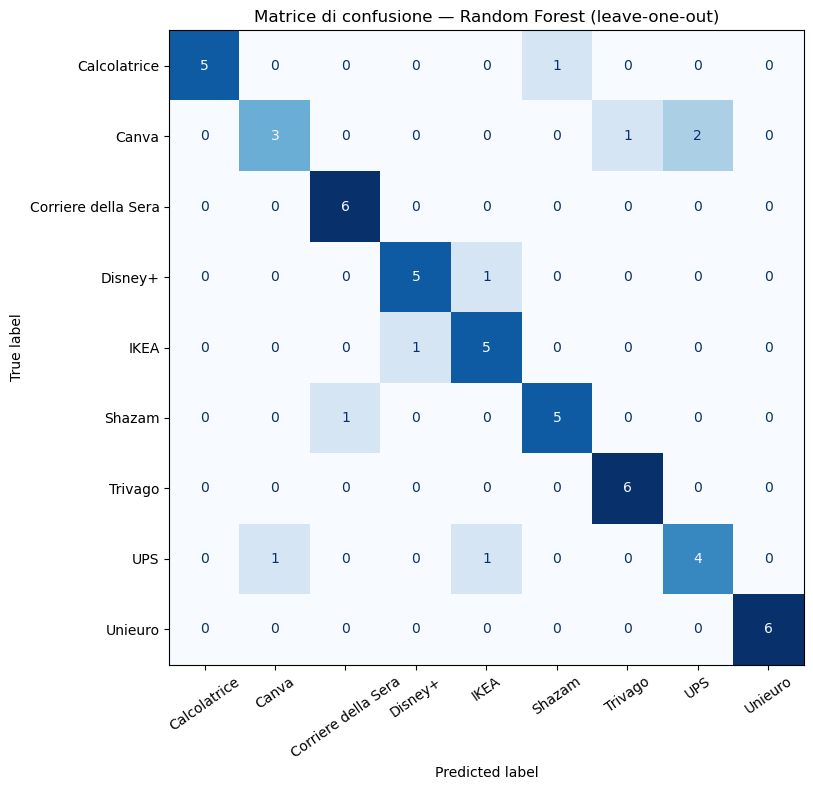

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
etichette_ordinate = sorted(app_con_abbastanza_campioni)
cm = confusion_matrix(reali, predette, labels=etichette_ordinate)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etichette_ordinate)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=35, colorbar=False)
plt.title("Matrice di confusione — Random Forest (leave-one-out)")
plt.tight_layout()
plt.savefig("matrice_confusione_rf.png", dpi=150)
plt.show()

### Interpretazione

Con le feature mirate (IAT medio e deviazione standard della dimensione), l'accuratezza sale a **83.3%**, il miglior risultato ottenuto (rispetto al 79.6% del modello con le sole 4 feature di base). Il miglioramento si concentra su **IKEA** e **Trivago**, portate al 100% di recall. La confusione residua si concentra ormai quasi esclusivamente sulla coppia **Canva / UPS** (50% di recall per entrambe).


## 8. Ricerca degli iperparametri

Per verificare se la configurazione di default del Random Forest fosse effettivamente la scelta migliore, è stata condotta una ricerca su una piccola griglia di combinazioni, validata con leave-one-out.

**Nota sui tempi**: una prima ricerca più estesa (144 combinazioni) è risultata troppo onerosa (>500 secondi) rispetto al beneficio atteso su un dataset di queste dimensioni; la griglia è stata quindi ridotta.


In [15]:
parametri_da_provare = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
}

ricerca = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parametri_da_provare,
    cv=LeaveOneOut(),
    scoring="accuracy",
    n_jobs=-1
)
ricerca.fit(X_full, y_full)

print("Migliori parametri trovati:", ricerca.best_params_)
print(f"Accuratezza con i migliori parametri: {ricerca.best_score_:.3f}")
print(f"Accuratezza con i parametri di default (Sezione 7): {acc_rf:.3f}")

Migliori parametri trovati: {'max_depth': None, 'n_estimators': 200}
Accuratezza con i migliori parametri: 0.833
Accuratezza con i parametri di default (Sezione 7): 0.833


### Interpretazione

La ricerca conferma che i parametri di default (`n_estimators=200`, profondità non limitata) erano già ottimali: nessun miglioramento ottenuto variando gli iperparametri. Il limite alle prestazioni risiede quindi nella dimensione del dataset e nella sovrapposizione intrinseca di alcune applicazioni, non nella configurazione del modello.


## 9. Confronto con un secondo algoritmo: XGBoost

Per verificare se un modello più sofisticato potesse ottenere risultati sensibilmente migliori sugli stessi dati (stesse 5 feature), è stato testato anche `XGBoost`, con la medesima validazione leave-one-out.


In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

pred_xgb, reali_xgb = [], []
for train_idx, test_idx in loo.split(X_full):
    clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                          random_state=42, eval_metric="mlogloss")
    clf.fit(X_full[train_idx], y_encoded[train_idx])
    pred = clf.predict(X_full[test_idx])
    pred_xgb.append(pred[0])
    reali_xgb.append(y_encoded[test_idx][0])

acc_xgb = accuracy_score(reali_xgb, pred_xgb)
print(f"Accuratezza XGBoost (leave-one-out): {acc_xgb:.3f}  ({acc_xgb*100:.1f}%)")
print(f"Confronto — Random Forest: {acc_rf*100:.1f}%  |  XGBoost: {acc_xgb*100:.1f}%\n")

pred_xgb_nomi = le.inverse_transform(pred_xgb)
reali_xgb_nomi = le.inverse_transform(reali_xgb)
print(classification_report(reali_xgb_nomi, pred_xgb_nomi, zero_division=0))

Accuratezza XGBoost (leave-one-out): 0.833  (83.3%)
Confronto — Random Forest: 83.3%  |  XGBoost: 83.3%

                     precision    recall  f1-score   support

       Calcolatrice       0.86      1.00      0.92         6
              Canva       0.67      0.67      0.67         6
Corriere della Sera       0.86      1.00      0.92         6
            Disney+       1.00      0.83      0.91         6
               IKEA       0.83      0.83      0.83         6
             Shazam       1.00      0.83      0.91         6
            Trivago       0.83      0.83      0.83         6
                UPS       0.67      0.67      0.67         6
            Unieuro       0.83      0.83      0.83         6

           accuracy                           0.83        54
          macro avg       0.84      0.83      0.83        54
       weighted avg       0.84      0.83      0.83        54



### Interpretazione

XGBoost converge esattamente sullo stesso valore di accuratezza di Random Forest (**83.3%**), pur con una distribuzione leggermente diversa degli errori tra le applicazioni (Random Forest più forte su IKEA/Trivago, XGBoost più forte su UPS). Questa convergenza, unita alla persistenza dell'errore su **Canva** in entrambi i modelli, indica che il limite residuo non è attribuibile alla scelta dell'algoritmo, ma a una reale sovrapposizione delle caratteristiche di traffico tra Canva e UPS.


## Verifica di robustezza: confronto tra leave-one-out e train/test split

La validazione leave-one-out, pur necessaria data la ridotta numerosità campionaria (6 campioni per applicazione), non costituisce una validazione completamente indipendente: le scelte di feature engineering sono state guidate osservando le prestazioni sull'intero dataset.

Per verificare quanto sarebbe stabile una validazione più tradizionale, è stato condotto un confronto con uno split train/test (70% training, 30% test), stratificato per applicazione e ripetuto con **10 suddivisioni casuali diverse**, sia per Random Forest sia per XGBoost, per capire se un'eventuale instabilità dipenda dall'algoritmo o dal dataset stesso.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, stratify=y_full, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
pred_test = clf.predict(X_test)

acc_split_rf = accuracy_score(y_test, pred_test)
print("=== Random Forest — Singolo split (70% training / 30% test) ===")
print(f"Accuratezza: {acc_split_rf:.3f}  ({acc_split_rf*100:.1f}%)")
print(f"Campioni: {len(y_train)} training, {len(y_test)} test\n")
print(classification_report(y_test, pred_test, zero_division=0))

=== Random Forest — Singolo split (70% training / 30% test) ===
Accuratezza: 0.824  (82.4%)
Campioni: 37 training, 17 test

                     precision    recall  f1-score   support

       Calcolatrice       1.00      1.00      1.00         2
              Canva       0.00      0.00      0.00         2
Corriere della Sera       0.67      1.00      0.80         2
            Disney+       1.00      1.00      1.00         2
               IKEA       1.00      1.00      1.00         2
             Shazam       1.00      0.50      0.67         2
            Trivago       0.67      1.00      0.80         2
                UPS       0.50      1.00      0.67         1
            Unieuro       1.00      1.00      1.00         2

           accuracy                           0.82        17
          macro avg       0.76      0.83      0.77        17
       weighted avg       0.77      0.82      0.78        17



In [18]:
risultati_split_rf = []
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.3, stratify=y_full, random_state=seed
    )
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    pred_test = clf.predict(X_test)
    risultati_split_rf.append(accuracy_score(y_test, pred_test))
    print(f"Seed {seed}: accuratezza = {risultati_split_rf[-1]*100:.1f}%")

print(f"\nMedia:   {np.mean(risultati_split_rf)*100:.1f}%")
print(f"Dev.std: {np.std(risultati_split_rf)*100:.1f}%")
print(f"Range:   {min(risultati_split_rf)*100:.1f}% - {max(risultati_split_rf)*100:.1f}%")
print(f"\n(per confronto, leave-one-out Random Forest = {acc_rf*100:.1f}%)")

Seed 0: accuratezza = 82.4%
Seed 1: accuratezza = 76.5%
Seed 2: accuratezza = 58.8%
Seed 3: accuratezza = 94.1%
Seed 4: accuratezza = 82.4%
Seed 5: accuratezza = 88.2%
Seed 6: accuratezza = 82.4%
Seed 7: accuratezza = 76.5%
Seed 8: accuratezza = 94.1%
Seed 9: accuratezza = 94.1%

Media:   82.9%
Dev.std: 10.3%
Range:   58.8% - 94.1%

(per confronto, leave-one-out Random Forest = 83.3%)


In [19]:
y_encoded_full = le.fit_transform(y_full)

risultati_split_xgb = []
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_encoded_full, test_size=0.3, stratify=y_encoded_full, random_state=seed
    )
    clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                          random_state=42, eval_metric="mlogloss")
    clf.fit(X_train, y_train)
    pred_test = clf.predict(X_test)
    risultati_split_xgb.append(accuracy_score(y_test, pred_test))
    print(f"Seed {seed}: accuratezza = {risultati_split_xgb[-1]*100:.1f}%")

print(f"\nMedia:   {np.mean(risultati_split_xgb)*100:.1f}%")
print(f"Dev.std: {np.std(risultati_split_xgb)*100:.1f}%")
print(f"Range:   {min(risultati_split_xgb)*100:.1f}% - {max(risultati_split_xgb)*100:.1f}%")
print(f"\n(per confronto, leave-one-out XGBoost = {acc_xgb*100:.1f}%)")

Seed 0: accuratezza = 82.4%
Seed 1: accuratezza = 70.6%
Seed 2: accuratezza = 58.8%
Seed 3: accuratezza = 94.1%
Seed 4: accuratezza = 64.7%
Seed 5: accuratezza = 88.2%
Seed 6: accuratezza = 82.4%
Seed 7: accuratezza = 76.5%
Seed 8: accuratezza = 88.2%
Seed 9: accuratezza = 82.4%

Media:   78.8%
Dev.std: 10.6%
Range:   58.8% - 94.1%

(per confronto, leave-one-out XGBoost = 83.3%)


### Interpretazione

| Modello | Leave-one-out | Media 10-split | Dev. standard | Range |
|---|---|---|---|---|
| Random Forest | 83.3% | 82.9% | ±10.3% | 58.8% - 94.1% |
| XGBoost | 83.3% | 78.8% | ±10.6% | 58.8% - 94.1% |

Le medie ottenute sui 10 split confermano sostanzialmente le accuratezze del leave-one-out, ma la deviazione standard è marcata per entrambi i modelli, con un **range identico** (58.8%-94.1%). Questa coincidenza indica che l'instabilità osservata non è attribuibile alla scelta dell'algoritmo, ma alla ridotta numerosità campionaria (6 campioni per classe): un singolo split è una stima altamente dipendente da quali specifici campioni vengono assegnati al test set (in particolare, i campioni di Canva, la classe più problematica, risultano decisivi per l'esito di ogni singolo split).

Questo risultato giustifica a posteriori la scelta della validazione leave-one-out come metodo principale in questo lavoro, poiché sfrutta l'intero dataset disponibile per la stima, riducendo la dipendenza dal singolo campionamento casuale che caratterizza invece un tradizionale split train/test su un numero di campioni così ridotto.


## Analisi approfondita del caso residuo: Canva / UPS

Le due applicazioni restano confuse tra loro (50% di recall reciproco) anche dopo l'introduzione delle feature mirate. Per capire perché, sono stati confrontati direttamente i valori delle feature per i due gruppi.


In [20]:
colonne_confronto = ["app", "etichetta"] + feature_columns
confronto = df_completo[df_completo["app"].isin(["Canva", "UPS"])][colonne_confronto]
confronto.sort_values(["app", "etichetta"])

,app,etichetta,MB_totali,rapporto_down_up,perc_pacchetti_pesanti,iat_medio_ms,dim_std
6,Canva,canva_1,92.58,28.79,75.3,2.123,567.4
7,Canva,canva_2,76.94,38.11,77.3,1.694,552.5
8,Canva,canva_3,65.56,104.48,87.3,0.945,432.5
9,Canva,canva_4,75.99,38.94,73.9,1.799,577.8
10,Canva,canva_5,63.82,258.93,94.2,0.419,301.9
11,Canva,canva_6,64.61,167.27,92.6,0.388,337.7
44,UPS,ups_1,76.30,275.05,94.5,0.336,298.4
45,UPS,ups_2,76.93,278.86,94.3,0.394,301.9
46,UPS,ups_3,64.47,273.72,94.5,0.436,295.8
47,UPS,ups_4,64.41,296.24,94.7,0.437,291.7


In [21]:
df_completo[df_completo["app"].isin(["Canva", "UPS"])].groupby("app")[feature_columns].agg(["mean", "std"])

MB_totali            rapporto_down_up             \
            mean        std             mean        std   
app                                                       
Canva  73.250000  11.112904       106.086667  91.881819   
UPS    70.211667   6.356991       244.361667  81.487247   

      perc_pacchetti_pesanti           iat_medio_ms               dim_std  \
                        mean       std         mean       std        mean   
app                                                                         
Canva              83.433333  9.050451     1.228000  0.746243  461.633333   
UPS                92.933333  3.888787     0.528167  0.230831  324.800000   

                   
              std  
app                
Canva  122.197376  
UPS     68.765486

### Interpretazione

Il confronto rivela che il **volume di traffico è quasi indistinguibile** tra le due applicazioni (Canva: 73.3 ± 11.1 MB; UPS: 70.2 ± 6.4 MB), la causa primaria della confusione, coerente con quanto già osservato.

Un'analisi della feature `durata_sec` (non più inclusa nel modello finale) ha mostrato inoltre una **variabilità interna molto elevata per Canva** (media 89.9s, deviazione standard 69.3s, quasi pari alla media stessa): un singolo campione (`canva_1`) dura 189.6 secondi, mentre altri due (`canva_5`, `canva_6`) durano solo 20-21 secondi, un fattore di variazione di quasi 10 volte per la stessa identica applicazione. Questo comportamento è verosimilmente riconducibile a condizioni di rete non controllate al momento della cattura (congestione, velocità di connessione variabile), non a un comportamento intrinsecamente diverso dell'applicazione, motivo per cui questa feature, pur discriminante in media, non è stata inclusa nel modello finale (la sua rimozione, non ha comunque modificato l'accuratezza).

**Test aggiuntivi condotti**: la sostituzione di `durata_sec` con `velocita_media_KB_s` non è stata effettuata, poiché tale feature è matematicamente derivata da volume e durata (velocità = byte/tempo) ed erediterebbe lo stesso rumore legato alle condizioni di rete del momento, non al comportamento dell'applicazione.

**Conclusione**: la confusione residua tra Canva e UPS rappresenta un limite intrinseco del dataset raccolto, le due applicazioni generano volumi di traffico e pattern di pacchetti sufficientemente simili da non essere pienamente distinguibili con le feature e il numero di campioni disponibili in questo lavoro, indipendentemente dall'algoritmo di classificazione impiegato.


## 10. Esperimenti di classificazione precoce (primi N pacchetti)

I risultati precedenti si basano su feature calcolate sull'**intera** cattura. Ispirandosi alla letteratura sulla classificazione precoce del traffico (FastFlow e, per l'approccio a sequenza di pacchetti, AppScanner), sono stati condotti due esperimenti per verificare se sia possibile classificare un'applicazione osservando **solo i primi N pacchetti** del flusso, un requisito importante per un eventuale utilizzo in tempo reale, a differenza dell'analisi a posteriori condotta finora.


### 10.1 Feature aggregate calcolate sui primi N pacchetti

In [26]:
def estrai_feature_primi_n_veloce(percorso_file, n_pacchetti):
    upload_bytes = 0
    download_bytes = 0
    n_pesanti = 0
    n_leggeri = 0
    contatore = 0

    with open(percorso_file, "rb") as f:
        header_globale = f.read(24)
        if len(header_globale) < 24:
            return None
        magic = struct.unpack("I", header_globale[:4])[0]
        endian = "<" if magic == 0xa1b2c3d4 else ">"

        while contatore < n_pacchetti:
            header_pacchetto = f.read(16)
            if len(header_pacchetto) < 16:
                break
            ts_sec, ts_usec, len_catturata, len_originale = struct.unpack(
                endian + "IIII", header_pacchetto
            )
            dati_pacchetto = f.read(len_catturata)
            contatore += 1

            if len(dati_pacchetto) >= 34:
                ip_header = dati_pacchetto[14:34]
                if ip_header[0] >> 4 == 4:
                    ip_src = socket.inet_ntoa(ip_header[12:16])
                    dim = len_originale
                    if ip_src.startswith("192.168.1."):
                        upload_bytes += dim
                    else:
                        download_bytes += dim
                    if dim > 1200:
                        n_pesanti += 1
                    else:
                        n_leggeri += 1

    totale = n_pesanti + n_leggeri
    if totale == 0:
        return None
    return {
        "byte_totali_n": upload_bytes + download_bytes,
        "rapporto_down_up_n": round(download_bytes / upload_bytes, 2) if upload_bytes > 0 else 0,
        "perc_pesanti_n": round(100 * n_pesanti / totale, 1),
    }

In [23]:
finestre = [20, 50, 100, 200, 500, 1000]
risultati_finestre = {}

for N in finestre:
    dati = []
    for etichetta, percorso in FILES.items():
        app = APP_DI.get(etichetta, etichetta)
        if app not in app_con_abbastanza_campioni or not os.path.exists(percorso):
            continue
        f = estrai_feature_primi_n_veloce(percorso, N)
        if f:
            f["etichetta"] = etichetta
            f["app"] = app
            dati.append(f)

    df_w = pd.DataFrame(dati)
    Xw = df_w[["byte_totali_n", "rapporto_down_up_n", "perc_pesanti_n"]].fillna(0).values
    yw = df_w["app"].values

    loo_w = LeaveOneOut()
    pred_w, reali_w = [], []
    for train_idx, test_idx in loo_w.split(Xw):
        clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(Xw[train_idx], yw[train_idx])
        pred_w.append(clf.predict(Xw[test_idx])[0])
        reali_w.append(yw[test_idx][0])

    acc = accuracy_score(reali_w, pred_w)
    risultati_finestre[N] = acc
    print(f"Primi {N:>4} pacchetti -> accuratezza: {acc*100:5.1f}%")

print(f"\n(per confronto, l'accuratezza sulla cattura intera era {acc_rf*100:.1f}%)")

Primi   20 pacchetti -> accuratezza:  18.5%
Primi   50 pacchetti -> accuratezza:  14.8%
Primi  100 pacchetti -> accuratezza:  18.5%
Primi  200 pacchetti -> accuratezza:  33.3%
Primi  500 pacchetti -> accuratezza:  13.0%
Primi 1000 pacchetti -> accuratezza:  14.8%

(per confronto, l'accuratezza sulla cattura intera era 83.3%)


**Interpretazione**: l'accuratezza non mostra un andamento monotono crescente verso il valore ottenuto sulla cattura intera, oscillando tra il 13% e il 33% circa. Le feature aggregate sui soli pacchetti iniziali non raggiungono l'affidabilità ottenuta osservando l'intera sessione.


### 10.2 Sequenza posizionale grezza (dimensione + direzione)

Un secondo approccio, più vicino al metodo descritto in AppScanner, fornisce al classificatore la sequenza **ordinata** di dimensione e direzione dei primi N pacchetti, invece di un aggregato.


In [24]:
def estrai_sequenza(percorso_file, n_pacchetti=15):
    primi_n = rdpcap(percorso_file, count=n_pacchetti)
    sequenza = []
    for p in primi_n:
        dim = len(p)
        direzione = 1 if (IP in p and p[IP].src.startswith("192.168.1.")) else 0
        sequenza.extend([dim, direzione])
    lunghezza_attesa = n_pacchetti * 2
    while len(sequenza) < lunghezza_attesa:
        sequenza.append(0)
    return sequenza[:lunghezza_attesa]

In [25]:
risultati_sequenza = {}

for N_PACCHETTI in [10, 15, 20, 30, 50]:
    X_seq, y_seq = [], []
    for etichetta, percorso in FILES.items():
        app = APP_DI.get(etichetta, etichetta)
        if app not in app_con_abbastanza_campioni or not os.path.exists(percorso):
            continue
        X_seq.append(estrai_sequenza(percorso, N_PACCHETTI))
        y_seq.append(app)

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    loo_s = LeaveOneOut()
    pred_s, reali_s = [], []
    for train_idx, test_idx in loo_s.split(X_seq):
        clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(X_seq[train_idx], y_seq[train_idx])
        pred_s.append(clf.predict(X_seq[test_idx])[0])
        reali_s.append(y_seq[test_idx][0])

    acc = accuracy_score(reali_s, pred_s)
    risultati_sequenza[N_PACCHETTI] = acc
    print(f"Primi {N_PACCHETTI:>3} pacchetti (sequenza grezza) -> accuratezza: {acc*100:5.1f}%")

print(f"\n(livello atteso da una scelta casuale: {100/len(app_con_abbastanza_campioni):.1f}%)")

Primi  10 pacchetti (sequenza grezza) -> accuratezza:  11.1%
Primi  15 pacchetti (sequenza grezza) -> accuratezza:   3.7%
Primi  20 pacchetti (sequenza grezza) -> accuratezza:   5.6%
Primi  30 pacchetti (sequenza grezza) -> accuratezza:  13.0%
Primi  50 pacchetti (sequenza grezza) -> accuratezza:  13.0%

(livello atteso da una scelta casuale: 11.1%)


**Interpretazione**: l'accuratezza ottenuta con la sequenza posizionale grezza è sistematicamente vicina o inferiore al livello casuale (~11%), spiegabile con il **disallineamento temporale** tra catture diverse della stessa applicazione: la posizione esatta in cui compare un dato pacchetto varia da una ripetizione all'altra per motivi legati alla rete, non all'applicazione. Le feature aggregate, indipendenti dall'ordine esatto dei pacchetti, risultano quindi molto più robuste a questa variabilità.


## 11. Sintesi dei risultati

| Esperimento | Accuratezza (leave-one-out) | Note |
|---|---|---|
| Feature di base (4): volume, durata, direzione, % pesanti | 79.6% | Prima versione |
| Ricerca iperparametri | 79.6% | Nessun miglioramento rispetto al default |
| XGBoost al posto di Random Forest | 81.5-83.3% | Miglioramento marginale |
| Set completo di 13 feature | 70.4% | **Peggiora**: overfitting su dataset ridotto |
| **Feature mirate (5): volume, direzione, % pesanti, IAT medio, dim_std** | **83.3%** | **Risultato finale, migliore ottenuto** |
| Feature aggregate, primi N pacchetti (N = 20...1000) | 13-33% | Instabile, molto inferiore alla cattura intera |
| Sequenza grezza, primi N pacchetti (N = 10...50) | ≈ livello casuale | Disallineamento posizionale tra catture |

### Conclusioni

1. **Il volume di traffico, combinato con poche feature mirate (direzione, IAT medio, variabilità della dimensione dei pacchetti), permette di distinguere applicazioni diverse con buona accuratezza** (83.3% su 9 classi, contro un livello casuale dell'11.1%).
2. **Aggiungere indiscriminatamente tutte le feature disponibili peggiora il risultato** (70.4%): con un dataset di 54 campioni, la selezione mirata delle feature, guidata dall'analisi di importanza e dalla comprensione del fenomeno, è risultata più efficace di un approccio esaustivo.
3. **Gli errori residui sono interpretabili e concentrati**: la confusione, inizialmente diffusa su quattro applicazioni (Canva, UPS, Unieuro, IKEA), si è ridotta con le feature mirate alla sola coppia Canva/UPS, per la quale un'analisi dedicata ha mostrato una reale sovrapposizione di volume di traffico, non risolvibile con le feature attualmente disponibili.
4. **La classificazione precoce (sui soli pacchetti iniziali) non ha prodotto risultati affidabili**, sia con feature aggregate sia con la sequenza grezza, un risultato negativo ma scientificamente informativo, che suggerisce come l'informazione discriminante emerga solo osservando una porzione sostanziale della sessione di traffico.
5. **I campioni parziali di Genshin Impact e Hay Day**, pur esclusi dalla validazione del classificatore, confermano coerentemente la tendenza generale osservata.

### Limiti dichiarati

- Dataset di dimensioni contenute (54 campioni validi su 9 classi), per via dei vincoli di tempo e dei limiti hardware del testbed
- Validazione *leave-one-out* anziché un vero split train/test indipendente
- Confronto di tipo *closed-world*: il classificatore riconosce solo le 9 applicazioni con cui è stato addestrato
- Una coppia di applicazioni (Canva, UPS) resta non pienamente distinguibile con le feature disponibili, per una reale sovrapposizione delle caratteristiche di traffico osservate
